# GWL Timeseries from Local CMIP6 Files
Computes GMST anomaly vs. 1850-1900 baseline with 20-yr rolling mean for each model × SSP.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))
import xarray as xr
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import warnings

from funcs_support import area_mean, get_params, utility_save, get_filepaths
dir_list = get_params()

In [2]:
exps = ['historical','ssp126','ssp245','ssp370','ssp585']
gwls_base = {'year': slice(1850, 1900)}
max_end_year = 2100
wwidth = 20

In [3]:
df = get_filepaths()
df = df.rename({'model':'source_id','exp':'experiment_id','run':'member_id',
                'varname':'variable_id','path':'zstore'}, axis=1)
df_tas = df.query('variable_id == "tas"')
print(df_tas.groupby(['source_id','experiment_id'])['zstore'].count())

source_id      experiment_id
CanESM5        historical       5
               ssp126           5
               ssp245           5
               ssp370           5
               ssp585           5
GFDL-ESM4      historical       3
               ssp126           1
               ssp245           3
               ssp370           1
               ssp585           1
IPSL-CM6A-LR   historical       6
               ssp126           5
               ssp245           5
               ssp370           5
               ssp585           5
MIROC6         historical       5
               ssp126           5
               ssp245           5
               ssp370           3
               ssp585           5
MPI-ESM1-2-LR  historical       5
               ssp126           5
               ssp245           5
               ssp370           5
               ssp585           5
Name: zstore, dtype: int64


In [4]:
modrun_groups = dict(tuple(df_tas.groupby(['source_id','member_id'])))
keys_all = list(modrun_groups.keys())
print('Model/run combos:', keys_all)

Model/run combos: [('CanESM5', 'r1i1p1f1'), ('CanESM5', 'r2i1p1f1'), ('CanESM5', 'r3i1p1f1'), ('CanESM5', 'r4i1p1f1'), ('CanESM5', 'r5i1p1f1'), ('GFDL-ESM4', 'r1i1p1f1'), ('GFDL-ESM4', 'r2i1p1f1'), ('GFDL-ESM4', 'r3i1p1f1'), ('IPSL-CM6A-LR', 'r1i1p1f1'), ('IPSL-CM6A-LR', 'r2i1p1f1'), ('IPSL-CM6A-LR', 'r3i1p1f1'), ('IPSL-CM6A-LR', 'r4i1p1f1'), ('IPSL-CM6A-LR', 'r5i1p1f1'), ('IPSL-CM6A-LR', 'r6i1p1f1'), ('MIROC6', 'r1i1p1f1'), ('MIROC6', 'r2i1p1f1'), ('MIROC6', 'r3i1p1f1'), ('MIROC6', 'r4i1p1f1'), ('MIROC6', 'r5i1p1f1'), ('MPI-ESM1-2-LR', 'r1i1p1f1'), ('MPI-ESM1-2-LR', 'r2i1p1f1'), ('MPI-ESM1-2-LR', 'r3i1p1f1'), ('MPI-ESM1-2-LR', 'r4i1p1f1'), ('MPI-ESM1-2-LR', 'r5i1p1f1')]


In [5]:
dss_out_list = []

for key in tqdm(keys_all):
    group = modrun_groups[key]
    
    if 'historical' not in group.experiment_id.values:
        print(f'{key}: no historical, skipping')
        continue
    
    # Load historical
    dsh = xr.open_dataset(group.loc[group.experiment_id=='historical','zstore'].values[0]).load()
    dsh = dsh.drop_vars(['time_bounds','time_bnds'], errors='ignore')
    
    if dsh.time.dt.year.min() > gwls_base['year'].start:
        print(f'{key}: historical does not cover base period, skipping')
        continue
    
    def to_annual_gmst(ds):
        ds = ds.drop_duplicates('time')
        gm = area_mean(ds).resample(time='1YS').mean()
        gm['time'] = gm['time'].dt.year
        return gm.rename({'time':'year'})
    
    gmst_hist = to_annual_gmst(dsh)
    baseline = float(gmst_hist['tas'].sel(**gwls_base).mean('year'))
    
    dss = {}
    for _, row in group[group.experiment_id != 'historical'].iterrows():
        exp = row['experiment_id']
        ds = xr.open_dataset(row['zstore']).load()
        ds = ds.drop_vars(['time_bounds','time_bnds'], errors='ignore')
        gmst_ssp = to_annual_gmst(ds)
        # Splice historical + SSP
        combined = xr.concat([gmst_hist.sel(year=slice(None,2014)),
                               gmst_ssp.sel(year=slice(2015,None))], dim='year')
        combined['tasanom'] = combined['tas'] - baseline
        gwl = combined.rolling(year=wwidth, center=True).mean().dropna('year')
        gwl = gwl.expand_dims({'experiment':[exp],'model':[key[0]],'run':[key[1]]})
        gwl = gwl.stack(memberid=['model','experiment','run']).reset_index(['memberid'])
        dss[exp] = gwl
    
    dss_out_list.append(xr.concat(list(dss.values()), dim='memberid'))
    print(f'{key[0]}: done')

dss_out = xr.concat(dss_out_list, dim='memberid')
print('\nShape:', dss_out.sizes)

  0%|          | 0/24 [00:00<?, ?it/s]

CanESM5: done


CanESM5: done


CanESM5: done


CanESM5: done


...

MPI-ESM1-2-LR: done


MPI-ESM1-2-LR: done


MPI-ESM1-2-LR: done


MPI-ESM1-2-LR: done


MPI-ESM1-2-LR: done

Shape: Frozen({'year': 232, 'memberid': 84, 'bnds': 2})


In [6]:
suffix = '_fromAmon'
output_fn = (dir_list['aux'] + 'gwl_ann_CMIP6_ALLEXPs_ALLRUNs_' +
             str(gwls_base['year'].start + wwidth//2) + '-' +
             str(max_end_year - wwidth//2) + suffix + '.nc')

dss_out['tasanom'].attrs = {'units':'K',
    'long_name':f'Rolling {wwidth}-yr mean GMST anomaly vs. {gwls_base["year"].start}-{gwls_base["year"].stop}'}
dss_out['tas'].attrs = {'units':'K', 'long_name':f'Rolling {wwidth}-yr mean near-surface GMST'}

utility_save(dss_out, output_fn)
print('Saved to', output_fn)

/burg-archive/home/mck2199/summer/summer_data/aux/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_fromAmon.nc removed to allow overwrite!


/burg-archive/home/mck2199/summer/summer_data/aux/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_fromAmon.nc saved!
Saved to /burg-archive/home/mck2199/summer/summer_data/aux/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_fromAmon.nc


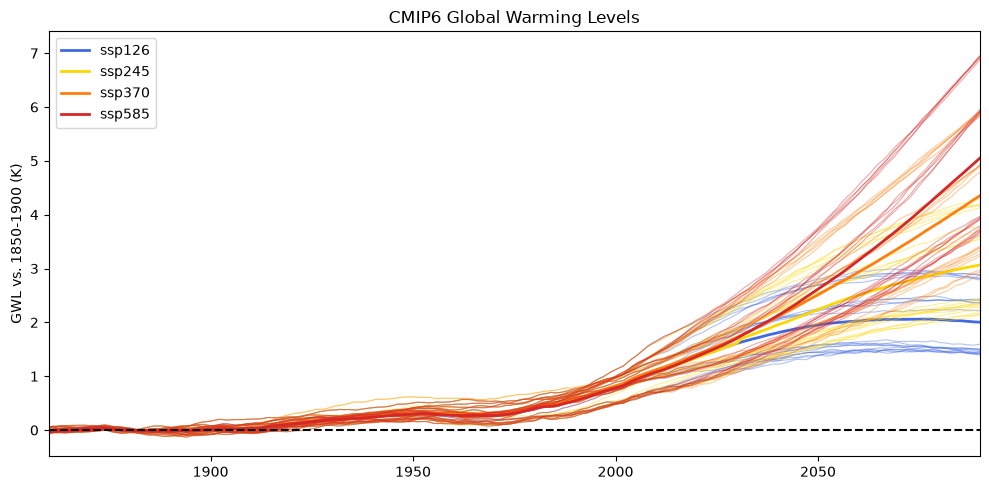

In [7]:
# Quick diagnostic plot
from matplotlib import pyplot as plt

colors = {'ssp126':'royalblue','ssp245':'gold','ssp370':'tab:orange','ssp585':'tab:red'}
fig, ax = plt.subplots(figsize=(10,5))

for exp in ['ssp126','ssp245','ssp370','ssp585']:
    sub = dss_out.isel(memberid=(dss_out.experiment.values==exp))
    for i in range(sub.sizes['memberid']):
        sub.isel(memberid=i).tasanom.plot(ax=ax, color=colors[exp], alpha=0.4, linewidth=0.8)
    sub.mean('memberid').tasanom.plot(ax=ax, color=colors[exp], linewidth=2, label=exp)

ax.axhline(0, color='k', linestyle='--')
ax.set_xlim(1860, 2090)
ax.set_ylabel('GWL vs. 1850-1900 (K)')
ax.set_xlabel('')
ax.set_title('CMIP6 Global Warming Levels')
ax.legend()
plt.tight_layout()
plt.show()